✅ Loaded 5 valid faces for class 'aqidi'
⚠️ No face found: dataset/train/bale/4.jpg
✅ Loaded 4 valid faces for class 'bale'
✅ Loaded 5 valid faces for class 'brozovic'
⚠️ No face found: dataset/train/bruyne/1.jpg
✅ Loaded 5 valid faces for class 'bruyne'
⚠️ No face found: dataset/train/cancelo/3.jpg
⚠️ No face found: dataset/train/cancelo/5.jpg
⚠️ No face found: dataset/train/cancelo/4.jpg
⚠️ No face found: dataset/train/cancelo/6.jpg
✅ Loaded 2 valid faces for class 'cancelo'
⚠️ No face found: dataset/train/casimiro/3.jpg
✅ Loaded 4 valid faces for class 'casimiro'
⚠️ No face found: dataset/train/costa/2.jpg
✅ Loaded 3 valid faces for class 'costa'
⚠️ No face found: dataset/train/cummins/2.jpg
✅ Loaded 2 valid faces for class 'cummins'
✅ Loaded 5 valid faces for class 'deligt'
⚠️ No face found: dataset/train/dias/3.jpg
⚠️ No face found: dataset/train/dias/6.jpg
✅ Loaded 4 valid faces for class 'dias'
✅ Loaded 5 valid faces for class 'fernandes'
⚠️ No face found: dataset/train/gordon/1

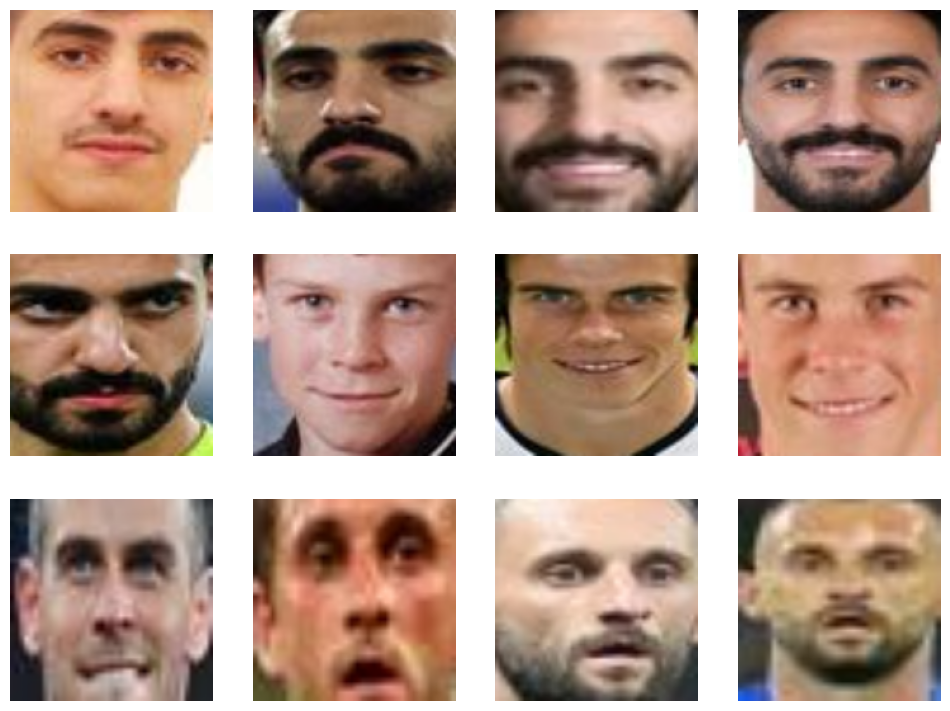

⚙️ Generating embeddings (FaceNet, may take a while)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/s

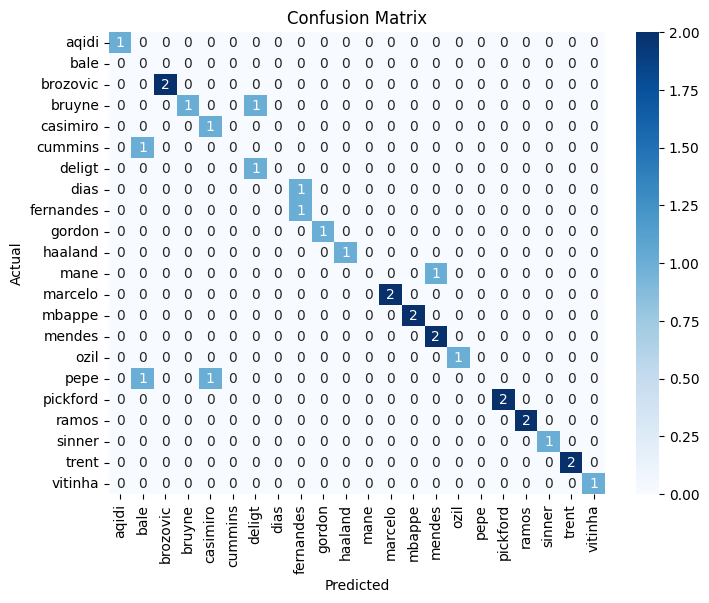

Model & encoder saved to svm_facenet_face_model.pkl

🔎 Predicting test image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted: ronaldo  (prob: 0.120)


In [5]:
# -*- coding: utf-8 -*-
"""
Face Recognition Pipeline (dlib -> FaceNet -> SVM)
Features:
- Multi-format image support (png, webp, jpg, jpeg, bmp)
- Auto-convert non-jpg to .jpg
- Remove unreadable/corrupt images
- Remove images with no detected face
- Face crop + resize (160x160)
- Generate FaceNet embeddings
- Train SVM classifier
- Save/load model
- Confusion matrix, classification report (safe for small datasets)
- Single image prediction
"""

import os
import cv2 as cv
import numpy as np
from PIL import Image
import dlib
from keras_facenet import FaceNet
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

# ----------------------------
# Config
# ----------------------------
TARGET_SIZE = (160, 160)
ALLOWED_EXT = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')
SAVED_MODEL_PATH = 'svm_facenet_face_model.pkl'
EMBEDDING_BATCH_SAVE = None  # Optional: save embeddings to disk

# ----------------------------
# FaceNet Embedder
# ----------------------------
embedder = FaceNet()

def get_embedding(face_img):
    """
    face_img: RGB numpy array (160,160,3)
    returns 512-D embedding vector from FaceNet
    """
    img = face_img.astype('float32')
    img = np.expand_dims(img, axis=0)
    emb = embedder.embeddings(img)
    return emb[0]

# ----------------------------
# FACELOADING Class
# ----------------------------
class FACELOADING:
    def __init__(self, directory, target_size=TARGET_SIZE):
        self.directory = directory
        self.target_size = target_size
        self.detector = dlib.get_frontal_face_detector()
        self.X = []
        self.Y = []

    def read_and_convert(self, filepath):
        try:
            img = Image.open(filepath).convert("RGB")
        except Exception as e:
            print(f"❌ Bad image removed: {filepath} ({e})")
            try: os.remove(filepath)
            except: pass
            return None, None

        ext = os.path.splitext(filepath)[1].lower()
        if ext not in ('.jpg', '.jpeg'):
            new_path = os.path.splitext(filepath)[0] + ".jpg"
            try:
                img.save(new_path, "JPEG", quality=95)
                if new_path != filepath:
                    try: os.remove(filepath)
                    except: pass
                filepath = new_path
            except Exception as e:
                print(f"❌ Conversion failed: {filepath} ({e})")
                return None, None

        img_np = np.array(img)
        return img_np, filepath

    def extract_face(self, filepath):
        img_rgb, final_path = self.read_and_convert(filepath)
        if img_rgb is None: return None

        faces = self.detector(img_rgb, 1)
        if not faces:
            print(f"⚠️ No face found: {final_path}")
            return None

        # Take first detected face
        d = faces[0]
        x1, y1, x2, y2 = max(d.left(),0), max(d.top(),0), min(d.right(), img_rgb.shape[1]), min(d.bottom(), img_rgb.shape[0])
        face = img_rgb[y1:y2, x1:x2]

        if face.size == 0 or face.shape[0] < 10 or face.shape[1] < 10:
            print(f"⚠️ Tiny/invalid face crop: {final_path}")
            return None

        face_resized = cv.resize(face, self.target_size)
        return face_resized

    def load_faces_from_class(self, class_dir):
        faces = []
        for fname in os.listdir(class_dir):
            fullpath = os.path.join(class_dir, fname)
            if not os.path.isfile(fullpath):
                continue
            face = self.extract_face(fullpath)
            if face is not None:
                faces.append(face)
        return faces

    def load_classes(self):
        for sub in sorted(os.listdir(self.directory)):
            subpath = os.path.join(self.directory, sub)
            if not os.path.isdir(subpath):
                continue
            faces = self.load_faces_from_class(subpath)
            labels = [sub] * len(faces)
            print(f"✅ Loaded {len(faces)} valid faces for class '{sub}'")
            self.X.extend(faces)
            self.Y.extend(labels)

        X_arr = np.asarray(self.X) if self.X else np.empty((0, *self.target_size, 3))
        Y_arr = np.asarray(self.Y) if self.Y else np.array([])
        return X_arr, Y_arr

    def plot_samples(self, limit=12):
        import math
        if len(self.X) == 0:
            print("No images to show.")
            return
        n = min(limit, len(self.X))
        cols = 4
        rows = math.ceil(n / cols)
        plt.figure(figsize=(cols * 3, rows * 3))
        for i in range(n):
            plt.subplot(rows, cols, i + 1)
            plt.imshow(self.X[i])
            plt.axis('off')
        plt.show()

# ----------------------------
# Train SVM classifier
# ----------------------------
def train_svm_with_metrics(EMBEDDED_X, Y_labels, test_size=0.25, random_state=17):
    encoder = LabelEncoder()
    Y_enc = encoder.fit_transform(Y_labels)

    # Stratify safe: only stratify if each class has >=2 samples
    from collections import Counter
    counts = Counter(Y_enc)
    if min(counts.values()) < 2:
        stratify_param = None
        print("⚠️ Dataset too small for stratify, training without stratify")
    else:
        stratify_param = Y_enc

    X_train, X_test, Y_train, Y_test = train_test_split(
        EMBEDDED_X, Y_enc, test_size=test_size, random_state=random_state, stratify=stratify_param
    )

    model = SVC(kernel='linear', probability=True, random_state=random_state)
    model.fit(X_train, Y_train)

    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    print("\n🔹 Training Results:")
    print(f"Train Accuracy : {accuracy_score(Y_train, Y_train_pred):.4f}")
    print(f"Test Accuracy  : {accuracy_score(Y_test, Y_test_pred):.4f}")

    # Safe classification report
    target_names = [encoder.classes_[i] for i in sorted(unique_labels(Y_test, Y_test_pred))]
    print("\n📄 Classification Report:")
    print(classification_report(Y_test, Y_test_pred, target_names=target_names))

    # Confusion matrix
    cm = confusion_matrix(Y_test, Y_test_pred, labels=sorted(unique_labels(Y_test, Y_test_pred)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return model, encoder

# ----------------------------
# Predict single image
# ----------------------------
def predict_image_from_path(model, encoder, image_path):
    detector = dlib.get_frontal_face_detector()
    try:
        img = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"Cannot open image: {e}")
        return None

    img_np = np.array(img)
    faces = detector(img_np, 1)
    if not faces:
        print("No face detected in test image.")
        return None

    d = faces[0]
    x1, y1, x2, y2 = max(d.left(),0), max(d.top(),0), min(d.right(), img_np.shape[1]), min(d.bottom(), img_np.shape[0])
    face = img_np[y1:y2, x1:x2]
    face_resized = cv.resize(face, TARGET_SIZE)

    emb = get_embedding(face_resized).reshape(1, -1)
    pred = model.predict(emb)
    name = encoder.inverse_transform(pred)[0]
    prob = np.max(model.predict_proba(emb))
    print(f"Predicted: {name}  (prob: {prob:.3f})")
    return name, prob

# ----------------------------
# Save / Load Model
# ----------------------------
def save_model_and_encoder(model, encoder, path=SAVED_MODEL_PATH):
    with open(path, 'wb') as f:
        pickle.dump({'model': model, 'encoder': encoder}, f)
    print(f"Model & encoder saved to {path}")

def load_model_and_encoder(path=SAVED_MODEL_PATH):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    return data['model'], data['encoder']

# ----------------------------
# Full pipeline
# ----------------------------
def run_pipeline(train_dir, test_image_path=None, plot_samples=True):
    loader = FACELOADING(train_dir, target_size=TARGET_SIZE)
    X_images, Y_labels = loader.load_classes()
    if X_images.size == 0:
        print("No valid faces found in training directory.")
        return

    if plot_samples:
        loader.plot_samples(limit=12)

    print("⚙️ Generating embeddings (FaceNet, may take a while)...")
    EMBEDDED = np.array([get_embedding(img) for img in X_images])

    if EMBEDDING_BATCH_SAVE:
        np.save(EMBEDDING_BATCH_SAVE, EMBEDDED)
        print(f"Saved embeddings to {EMBEDDING_BATCH_SAVE}.npy")

    model, encoder = train_svm_with_metrics(EMBEDDED, Y_labels)
    save_model_and_encoder(model, encoder)

    if test_image_path:
        print("\n🔎 Predicting test image...")
        predict_image_from_path(model, encoder, test_image_path)

    return model, encoder

# ----------------------------
# Run example
# ----------------------------
if __name__ == "__main__":
    train_dir = "dataset/train"       # folder with subfolders per person
    test_image = "dataset/test/ronaldo/ronaldo.jpg"   # optional test image

    run_pipeline(train_dir, test_image_path=test_image, plot_samples=True)